In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("All libraries imported successfully!")

All libraries imported successfully!


# Customer Churn Predictor

## Objective
The objective of this project is to predict whether a customer will leave a telecom company based on customer information using Machine Learning classification algorithms.

### Steps
- Data Collection
- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Building
- Model Evaluation
- Conclusion

In [76]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [77]:
# Load Dataset

df = pd.read_csv("dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Information

In [78]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# Statistical summary of numerical columns

df.describe()

In [79]:
# Statistical summary of numerical columns

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Check Missing Values

In [80]:
# Check missing values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [81]:
# Dataset Shape

print("Rows and Columns:", df.shape)

Rows and Columns: (7043, 21)


In [82]:
# Display column names

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

## Data Cleaning

In [83]:
# Check data types

df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [84]:
# Check unique values in TotalCharges

df['TotalCharges'].unique()

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str

In [85]:
# Count blank values in TotalCharges

(df['TotalCharges'] == " ").sum()

np.int64(11)

In [86]:
# Replace blank values with NaN

df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

In [87]:
# Convert TotalCharges to numeric

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [88]:
# Check missing values

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [89]:
# Remove missing values

df = df.dropna()

In [90]:
# Check dataset shape after cleaning

df.shape

(7032, 21)

# Exploratory Data Analysis (EDA)

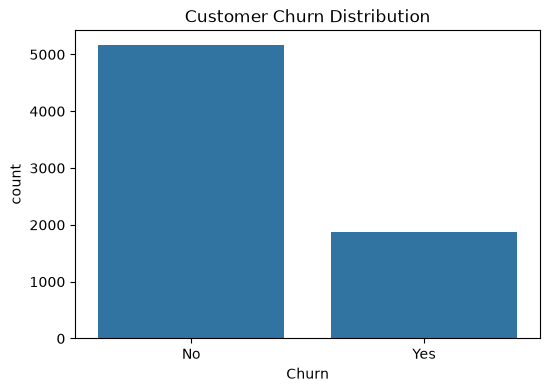

In [91]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

In [92]:
plt.savefig("images/Customer_Churn_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [93]:
import matplotlib.pyplot as plt

In [94]:
plt.savefig("images/Customer_Churn_Distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

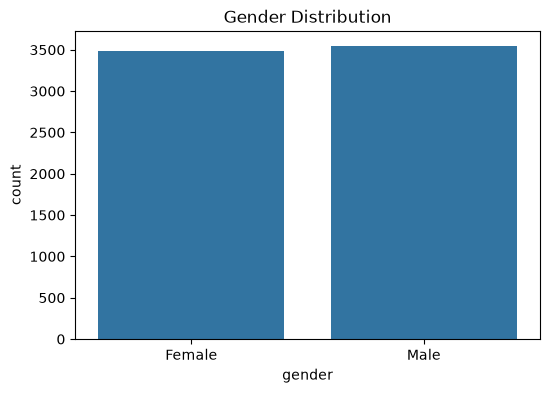

In [95]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")
plt.show()

In [96]:
import matplotlib.pyplot as plt


In [97]:
plt.savefig("images/Gender_Distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

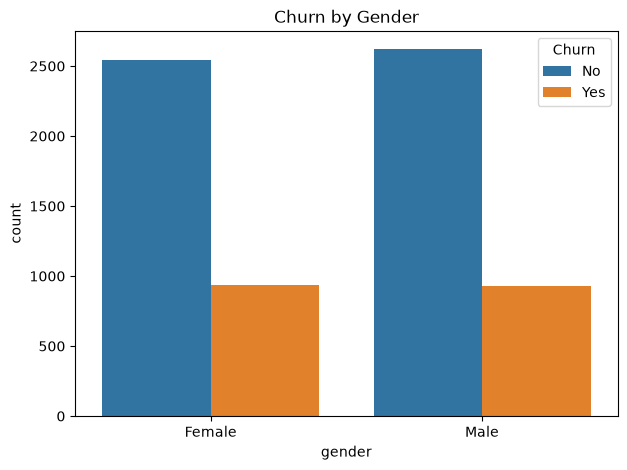

In [98]:
plt.figure(figsize=(7,5))

sns.countplot(x='gender', hue='Churn', data=df)

plt.title("Churn by Gender")
plt.show()

In [99]:
import matplotlib.pyplot as plt

In [100]:
plt.savefig("images/Churn_By_Gender.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

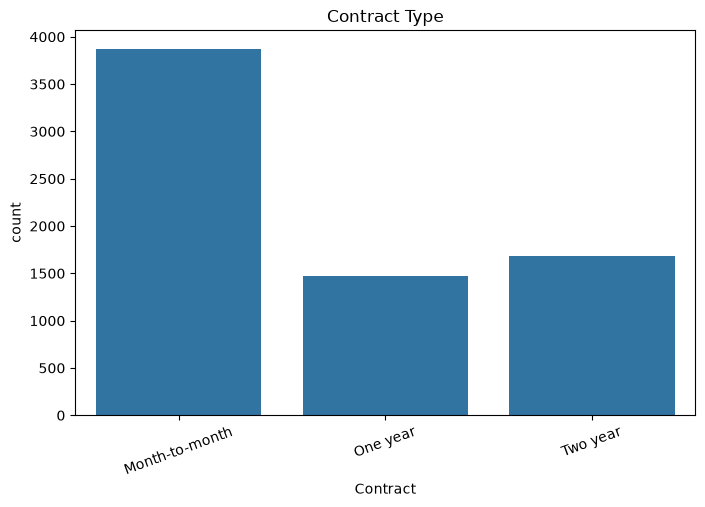

In [101]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', data=df)

plt.title("Contract Type")
plt.xticks(rotation=20)
plt.show()

In [102]:
import matplotlib.pyplot as plt

In [103]:
plt.savefig("images/Contract_Type.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

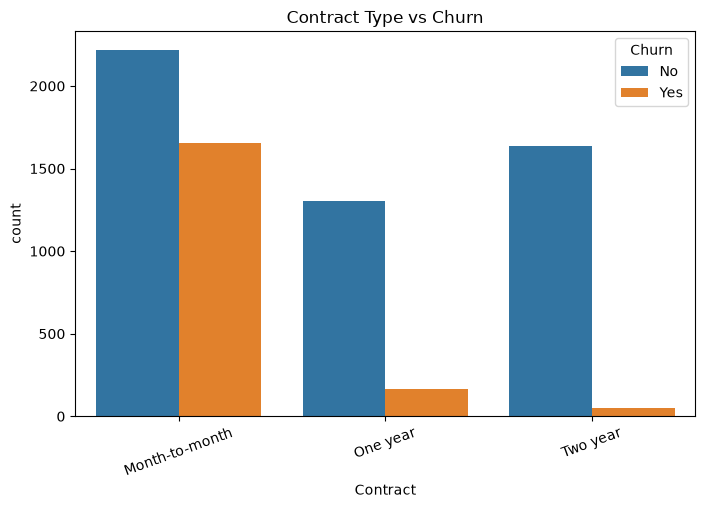

In [104]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()

In [105]:
import matplotlib.pyplot as plt

In [106]:
plt.savefig("images/Contract_VS_Churn.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

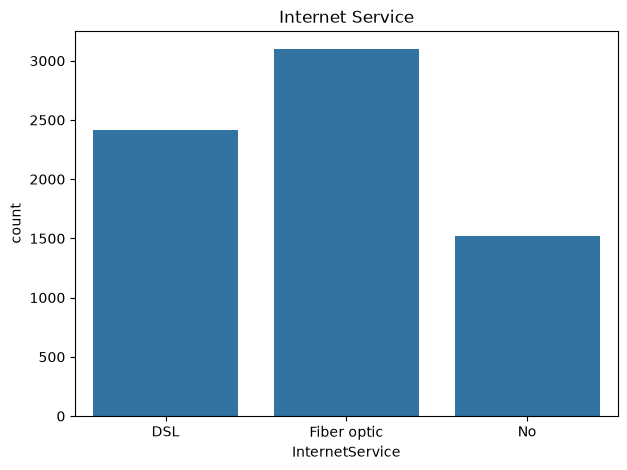

In [107]:
plt.figure(figsize=(7,5))

sns.countplot(x='InternetService', data=df)

plt.title("Internet Service")
plt.show()

In [108]:
import matplotlib.pyplot as plt

In [109]:
plt.savefig("images/Internet_Service.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

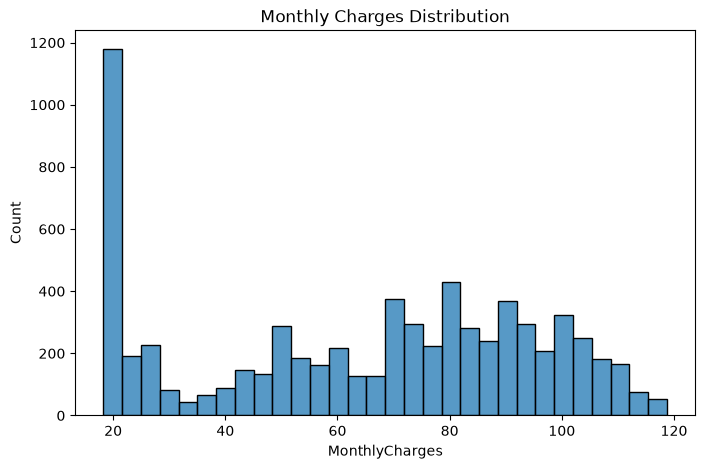

In [110]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyCharges'], bins=30)

plt.title("Monthly Charges Distribution")
plt.show()

In [111]:
import matplotlib.pyplot as plt

In [112]:
plt.savefig("images/Monthly_Charges_Distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

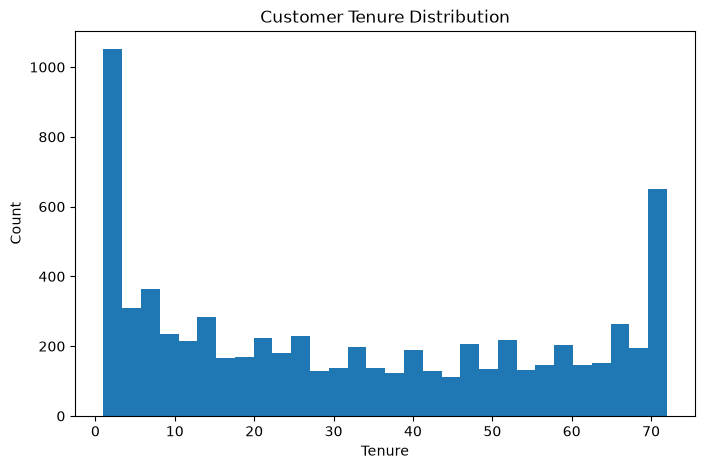

In [113]:
plt.figure(figsize=(8,5))
plt.hist(df["tenure"], bins=30)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Count")

plt.savefig("images/Customer_tenure_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [114]:
import matplotlib.pyplot as plt

In [115]:
plt.savefig("images/Customer_Tenure_Distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# Data Preprocessing

In [116]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Feature Selection

In [117]:
X = df.drop('Churn', axis=1)

y = df['Churn']

print(X.shape)
print(y.shape)

(7032, 20)
(7032,)


# Train-Test Split

In [118]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5625, 20)
(1407, 20)


# Logistic Regression Model

In [ ]:
# Remove customerID column
df = df.drop('customerID', axis=1)

# Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn']

print(X.shape)
print(y.shape)

(7032, 19)
(7032,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

In [ ]:
# Remove customerID
df = df.drop("customerID", axis=1)

# Create Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

print(X.shape)
print(y.shape)

In [ ]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7874911158493249


# Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7249466950959488


# Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7853589196872779


# Model Comparison

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.787491
1,Decision Tree,0.724947
2,Random Forest,0.785359


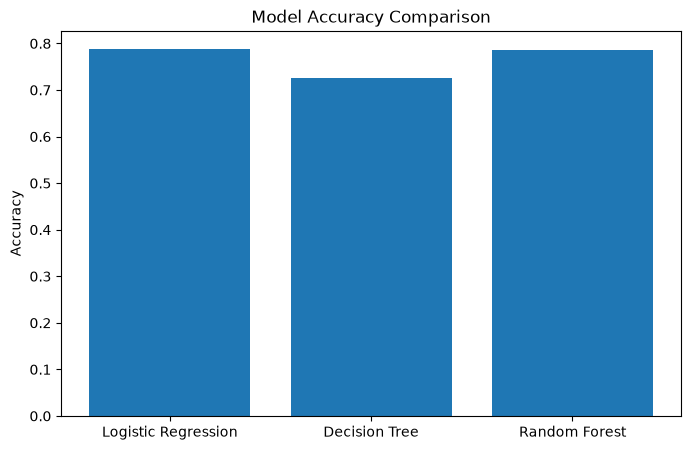

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.savefig("images/Model_Accuracy_Comparison.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# Confusion Matrix

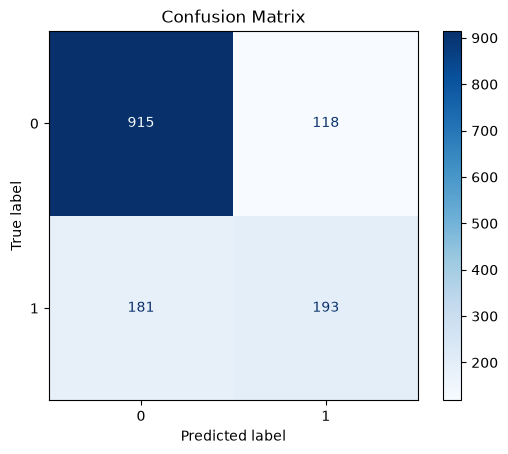

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.savefig("images/Confusion_Matrix.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1033
         Yes       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



# Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.193409
2,MonthlyCharges,0.169758
1,tenure,0.167572
10,InternetService_Fiber optic,0.039999
28,PaymentMethod_Electronic check,0.035016
13,OnlineSecurity_Yes,0.028905
25,Contract_Two year,0.028618
4,gender_Male,0.026971
19,TechSupport_Yes,0.025829
26,PaperlessBilling_Yes,0.025044


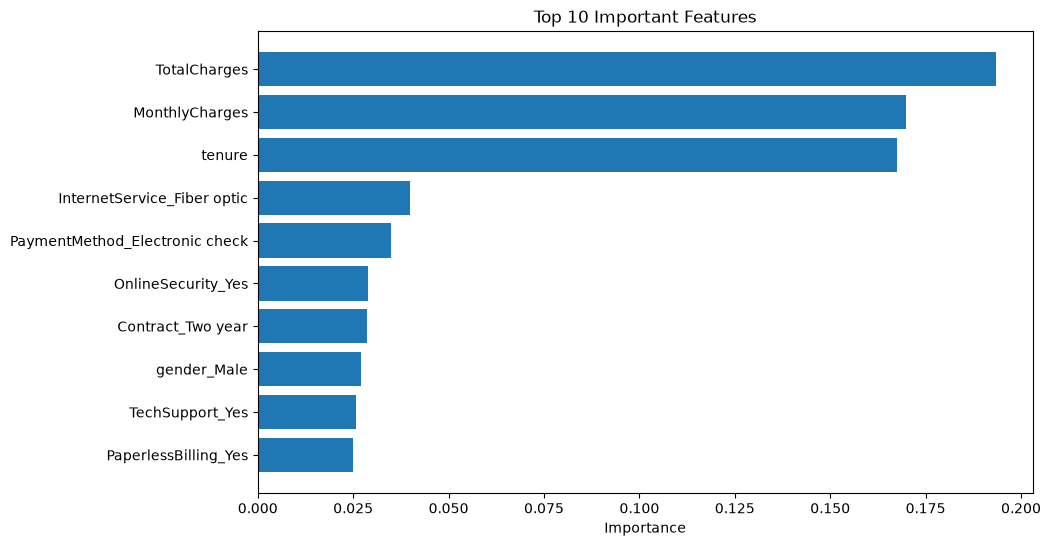

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.show()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.savefig("images/Important_Features.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# Save Model

In [ ]:
import joblib

joblib.dump(rf, "models/customer_churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!
